# Agriculture

In [7]:
!pip cache purge --quiet

In [8]:
!conda install --quiet -c conda-forge \
    r-base=4.4.3 \
    r-essentials=4.4 \
    r-rjava=1.0_11 \
    r-rjdbc=0.2_10 \
    r-leaflet=2.2.2 \
    rpy2=3.6.2 \
    -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - r-base=4.4.3
    - r-essentials=4.4
    - r-leaflet=2.2.2
    - r-rjava=1.0_11
    - r-rjdbc=0.2_10
    - rpy2=3.6.2


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _r-mutex-1.0.1             |      anacondar_1           3 KB  conda-forge
    alsa-lib-1.2.16.1          |       hb03c661_0         578 KB  conda-forge
    binutils_impl_linux-64-2.40|       ha885e6a_0         5.5 MB  conda-forge
    binutils_linux-64-2.40     |       hb3c18ed_9          29 KB  conda-forge
    blosc-1.21.6               |       he440d0b_1          47 KB  conda-forge
    bwidget-1.10.1             |       ha770c72_1         127 KB  conda-forge
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates

In [10]:
import ctypes
import IPython

In [11]:
ctypes.CDLL("libstdc++.so.6", mode = ctypes.RTLD_GLOBAL)

IPython.Application.instance().kernel.do_shutdown(restart = True)

{'status': 'ok', 'restart': True}

In [5]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /opt/conda/lib/R
INFO:rpy2.situation:R library path: /usr/local/nvidia/lib64:
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/local/nvidia/lib64:
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface:R is already initialized. No need to initialize.


In [6]:
import base64
import mimetypes

from IPython.display import HTML
from rpy2.robjects import r, StrVector, IntVector
from singlestoredb.management import get_secret

In [7]:
%%R

library(dplyr)
library(ggplot2)
library(htmlwidgets)
library(knitr)
library(leaflet)
library(randomForest)
library(RColorBrewer)
library(RJDBC)

# Increase plot size in Jupyter
options(repr.plot.width = 12, repr.plot.height = 8)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

randomForest 4.7-1.2
Type rfNews() to see new features/changes/bug fixes.

Attaching package: ‘randomForest’

The following object is masked from ‘package:ggplot2’:

    margin

The following object is masked from ‘package:dplyr’:

    combine

Loading required package: DBI
Loading required package: rJava


In [8]:
%%R
# If you've forked this repo, change OWNER to your GitHub username.
# REPO and BRANCH will normally stay the same unless you renamed them.
OWNER <- "singlestore-cookbook"
REPO <- "singlestore-cookbook.github.io"
BRANCH <- "refs/heads/main"
BASE_URL <- paste0("https://raw.githubusercontent.com/", OWNER, "/", REPO, "/", BRANCH, "/code/part-ml/agriculture-analytics-using-r/datasets")

In [9]:
%%R

agri_csv_url <- paste0(BASE_URL, "/agriculture.csv")

agri_df <- read.csv(agri_csv_url, stringsAsFactors = FALSE)
kable(head(agri_df, 10))



|province           | latitude| longitude| rainfall| soil_ph|crop     | yield| year|
|:------------------|--------:|---------:|--------:|-------:|:--------|-----:|----:|
|West Kalimantan    |   0.7313|  112.3939|     3284|    5.05|Palm Oil |  3.55| 2023|
|Riau Islands       |  -0.1721|  104.6600|     2549|    6.51|Coconut  |  3.61| 2024|
|Southeast Sulawesi |  -3.7564|  122.4373|     2033|    5.33|Rice     |  4.88| 2022|
|Bali               |  -8.2479|  114.5624|     2412|    5.92|Coffee   |  1.20| 2021|
|East Nusa Tenggara |  -8.4012|  123.4993|     1226|    5.51|Rice     |  4.36| 2023|
|North Maluku       |   0.9559|  128.0133|     2707|    6.31|Coconut  |  3.86| 2016|
|North Sulawesi     |   1.5828|  124.9783|     2548|    5.73|Coconut  |  4.11| 2019|
|Aceh               |   4.5620|   96.3068|     2135|    5.73|Corn     |  3.35| 2022|
|Central Sulawesi   |  -1.4216|  120.4337|     2197|    5.74|Rice     |  4.59| 2017|
|Central Kalimantan |  -2.8499|  114.2137|     2798|    4.65|Ru

In [10]:
%%R

agri_df$year <- as.integer(agri_df$year)

# Convert year to a factor in the full dataset, ascending order
agri_df$year <- factor(agri_df$year, levels = sort(unique(agri_df$year)))

# Ensure crop is a factor
agri_df$crop <- as.factor(agri_df$crop)

# Filter to major crops for plotting
major_crops <- c("Rice", "Corn", "Coffee", "Palm Oil", "Rubber", "Cocoa")
plot_df <- agri_df %>% filter(crop %in% major_crops)

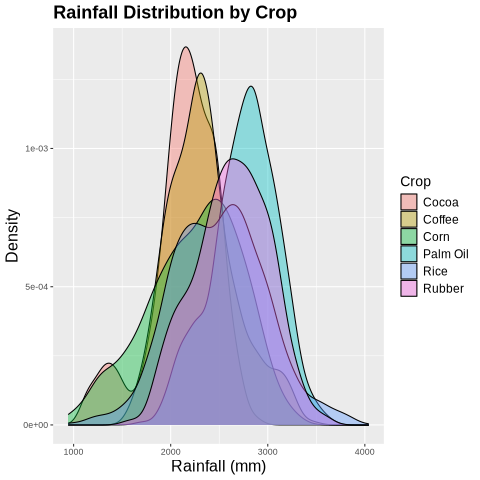

In [11]:
%%R

ggplot(plot_df, aes(x = rainfall, fill = crop)) +
    geom_density(alpha = 0.4) +
    theme(
        axis.title = element_text(size = 16),
        plot.title = element_text(size = 18, face = "bold"),
        legend.title = element_text(size = 14),
        legend.text = element_text(size = 12)
    ) +
    labs(
        title = "Rainfall Distribution by Crop",
        x = "Rainfall (mm)",
        y = "Density",
        fill = "Crop"
    )

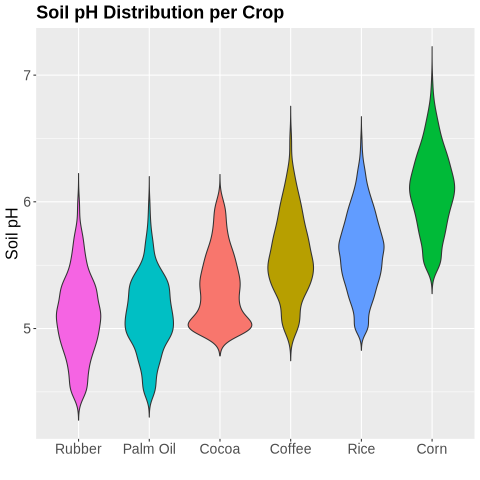

In [12]:
%%R

ggplot(plot_df, aes(x = reorder(crop, soil_ph, FUN = median), y = soil_ph, fill = crop)) +
    geom_violin(trim = FALSE, show.legend = FALSE) +
    theme(
        axis.title = element_text(size = 16),
        axis.text.y = element_text(size = 14),
        axis.text.x = element_text(size = 14),
        plot.title = element_text(size = 18, face = "bold")
    ) +
    labs(
        title = "Soil pH Distribution per Crop",
        x = "",
        y = "Soil pH"
    )

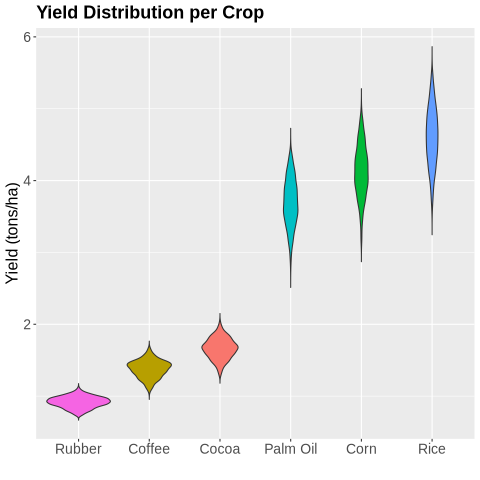

In [13]:
%%R

ggplot(plot_df, aes(x = reorder(crop, yield, FUN = median), y = yield, fill = crop)) +
    geom_violin(trim = FALSE, show.legend = FALSE) +
    theme(
        axis.title = element_text(size = 16),
        axis.text.y = element_text(size = 14),
        axis.text.x = element_text(size = 14),
        plot.title = element_text(size = 18, face = "bold")
    ) +
    labs(
        title = "Yield Distribution per Crop",
        x = "",
        y = "Yield (tons/ha)"
    )

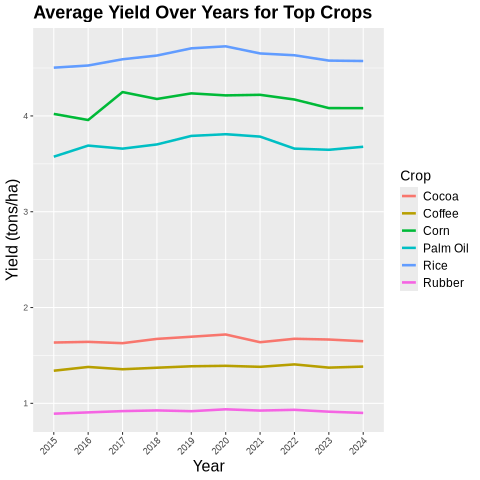

In [14]:
%%R

ggplot(plot_df, aes(x = year, y = yield, color = crop, group = crop)) +
    stat_summary(fun = mean, geom = "line", linewidth = 1.2) +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        axis.title = element_text(size = 16),
        plot.title = element_text(size = 18, face = "bold"),
        legend.text = element_text(size = 12),
        legend.title = element_text(size = 14)
    ) +
    labs(
        title = "Average Yield Over Years for Top Crops",
        x = "Year",
        y = "Yield (tons/ha)",
        color = "Crop"
    )

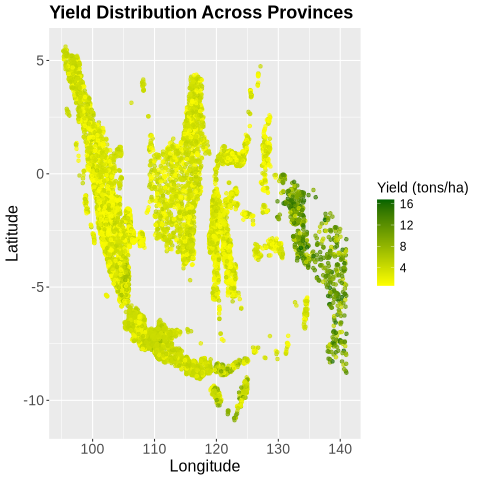

In [15]:
%%R

ggplot(agri_df, aes(x = longitude, y = latitude, color = yield)) +
    geom_point(alpha = 0.7) +
    scale_color_gradient(low = "yellow", high = "darkgreen") +
    theme(
        axis.text = element_text(size = 14),
        axis.title = element_text(size = 16),
        plot.title = element_text(size = 18, face = "bold"),
        legend.text = element_text(size = 12),
        legend.title = element_text(size = 14)
    ) +
    labs(title = "Yield Distribution Across Provinces",
        x = "Longitude",
        y = "Latitude",
        color = "Yield (tons/ha)"
    )

In [16]:
%%R

set.seed(42)

# Train/test split
train_index <- sample(seq_len(nrow(agri_df)), size = 0.8 * nrow(agri_df))
train <- agri_df[train_index, ]
test <- agri_df[-train_index, ]

In [17]:
%%R

# Train Random Forest
rf_model <- randomForest(
    yield ~ latitude + longitude + rainfall + soil_ph + crop + year,
    data = train,
    ntree = 250
)

print(rf_model)


Call:
 randomForest(formula = yield ~ latitude + longitude + rainfall +      soil_ph + crop + year, data = train, ntree = 250) 
               Type of random forest: regression
                     Number of trees: 250
No. of variables tried at each split: 2

          Mean of squared residuals: 0.1213262
                    % Var explained: 97.87


In [18]:
%%R

# Predict and evaluate
pred <- predict(rf_model, newdata = test)

In [19]:
%%R

# Correlation between predicted and actual yields
correlation <- cor(pred, test$yield)
cat("Correlation between predicted and actual yield:", round(correlation, 3), "\n")

# Calculate Root Mean Squared Error (RMSE)
rmse <- sqrt(mean((pred - test$yield)^2))
cat("Root Mean Squared Error (RMSE):", round(rmse, 3), "\n")

# Calculate Mean Absolute Error (MAE)
mae <- mean(abs(pred - test$yield))
cat("Mean Absolute Error (MAE):", round(mae, 3), "\n")

Correlation between predicted and actual yield: 0.989 
Root Mean Squared Error (RMSE): 0.358 
Mean Absolute Error (MAE): 0.245 


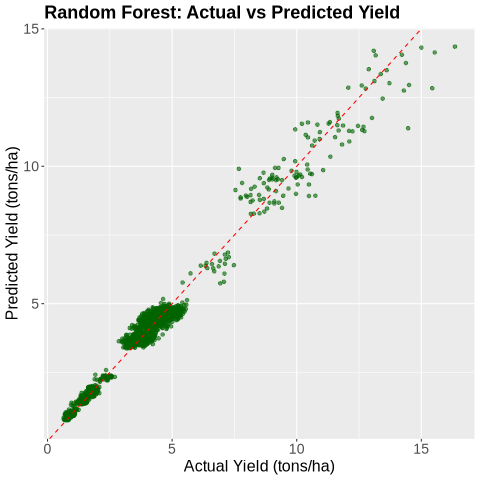

In [20]:
%%R

# Visualize actual vs predicted
ggplot(data.frame(actual = test$yield, predicted = pred), aes(x = actual, y = predicted)) +
    geom_point(alpha = 0.6, color = "darkgreen") +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
    theme(
        axis.text = element_text(size = 14),
        axis.title = element_text(size = 16),
        plot.title = element_text(size = 18, face = "bold")
    ) +
    labs(
        title = "Random Forest: Actual vs Predicted Yield",
        x = "Actual Yield (tons/ha)",
        y = "Predicted Yield (tons/ha)"
    )

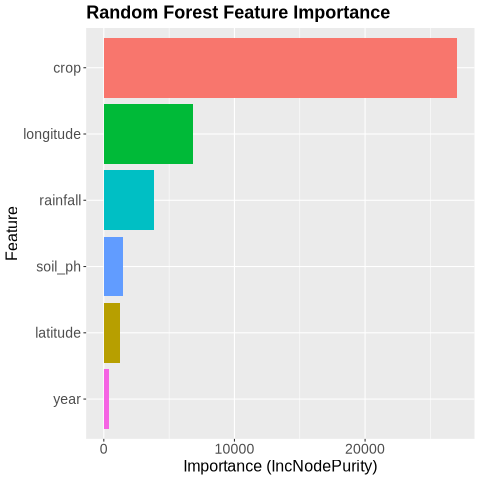

In [21]:
%%R

# Feature importance
importance_df <- as.data.frame(importance(rf_model))
importance_df$feature <- rownames(importance_df)
importance_df <- importance_df %>% arrange(desc(IncNodePurity))

ggplot(importance_df, aes(x = reorder(feature, IncNodePurity), y = IncNodePurity, fill = feature)) +
    geom_col(show.legend = FALSE) +
    coord_flip() +
    theme(
        axis.text = element_text(size = 14),
        axis.title = element_text(size = 16),
        plot.title = element_text(size = 18, face = "bold")
    ) +
    labs(
        title = "Random Forest Feature Importance",
        x = "Feature",
        y = "Importance (IncNodePurity)"
    )

In [22]:
%%R

# Predict on full dataset for mapping
agri_df$predicted_yield <- predict(rf_model, newdata = agri_df)

In [23]:
%%R

# Assume agri_df has lat, lon, year, predicted_yield
agri_df <- agri_df %>%
    mutate(
        year = as.integer(as.character(year)),
        predicted_yield = as.numeric(predicted_yield)
    )

# Define a high-contrast palette
pal <- colorFactor(rainbow(length(unique(agri_df$crop))), domain = agri_df$crop)

# Create leaflet map with layers for each year
m <- leaflet() %>% addTiles()

for (yr in sort(unique(agri_df$year))) {
    year_data <- filter(agri_df, year == yr)

    m <- m %>%
        addCircleMarkers(
            data = year_data,
            lng = ~longitude,
            lat = ~latitude,
            radius = 6,
            color = ~pal(crop),
            stroke = TRUE, fillOpacity = 0.9,
            popup = ~paste0(
                "<b>Crop:</b> ", crop, "<br/>",
                "<b>Year:</b> ", year, "<br/>",
                "<b>Predicted Yield:</b> ", round(predicted_yield, 2), " tons/ha<br/>",
                "<b>Soil pH:</b> ", round(soil_ph, 2), "<br/>",
                "<b>Rainfall:</b> ", rainfall, " mm"
            ),
            group = paste0("Year ", yr)
        )
}

# Add legend + layer control
m <- m %>%
    addLegend(
        pal = pal,
        values = agri_df$crop,
        title = "Crop Type",
        opacity = 1
    ) %>%
    addLayersControl(
        overlayGroups = paste0("Year ", sort(unique(agri_df$year))),
        options = layersControlOptions(collapsed = FALSE)
    )

# Save to a local file
crop_map <- "crop_map.html"
saveWidget(m, crop_map, selfcontained = TRUE)

In [24]:
crop_map = str(r["crop_map"][0])
mime_type, _ = mimetypes.guess_type(crop_map)

with open(crop_map, "rb") as f:
    data = f.read()
b64 = base64.b64encode(data).decode()
href = f'<a download="{crop_map}" href="data:{mime_type};base64,{b64}">Download {crop_map}</a>'
HTML(href)

<div class="alert alert-block alert-warning">
    <b class="fa fa-solid fa-exclamation-circle"></b>
    <div>
        <p><b>Action Required</b></p>
        <p>Select the database from the drop-down menu at the top of this notebook. It updates the <b>connection_url</b> which is used by SQLAlchemy to make connections to the selected database.</p>
    </div>
</div>

In [26]:
%%R

# Function to set up the JDBC driver for SingleStore
setup_driver <- function() {
    # URL for downloading the SingleStore JDBC client JAR
    driver_url <- "https://repo1.maven.org/maven2/com/singlestore/singlestore-jdbc-client/1.2.8/singlestore-jdbc-client-1.2.8.jar"

    # Class name of the JDBC driver
    driver <- "com.singlestore.jdbc.Driver"

    # Directory to store the JAR file
    local_dir <- "jars"
    dir.create(local_dir, showWarnings = FALSE, recursive = TRUE)

    # Path to the local copy of the driver JAR
    driver_file <- file.path(local_dir, basename(driver_url))

    # Download the driver JAR if it does not already exist locally
    if (!file.exists(driver_file)) {
        download.file(driver_url, destfile = driver_file, mode = "wb", quiet = TRUE)
    }

    # Load and return the JDBC driver
    JDBC(driver, driver_file)
}

# Function to connect to the SingleStore database
connect_db <- function(drv, host, port, database, user, password) {
    # Construct the JDBC connection URL
    url <- paste0("jdbc:singlestore://", host, ":", port, "/", database)

    # Establish and return a database connection
    dbConnect(drv, url = url, user = user, password = password)
}

In [27]:
from sqlalchemy import *

db_connection = create_engine(connection_url)
url = db_connection.url

r.assign("host", url.host);
r.assign("port", int(url.port));
r.assign("database", url.database);
r.assign("user", "admin")
r.assign("password", get_secret("password"));

In [28]:
%%R

# Establish the JDBC connection
drv <- setup_driver()
conn <- connect_db(drv, host, port, database, user, password)

In [29]:
%%R

# Write the dataset to the database
dbWriteTable(conn, "agriculture", agri_df, overwrite = TRUE)

In [30]:
%%R

# Close the JDBC connection
dbDisconnect(conn)

[1] TRUE
